In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Display all columns
pd.set_option('display.max_columns', None)

In [3]:
# ============================================================
# 2. LOAD ALL CSV FILES
# ============================================================

import pandas as pd

sales = pd.read_csv(r"C:\Users\USER\Desktop\Retail_Sales_Capstone\data\raw\salesdata.csv")
customers = pd.read_csv(r"C:\Users\USER\Desktop\Retail_Sales_Capstone\data\raw\customers.csv")
products = pd.read_csv(r"C:\Users\USER\Desktop\Retail_Sales_Capstone\data\raw\products.csv")
stores = pd.read_csv(r"C:\Users\USER\Desktop\Retail_Sales_Capstone\data\raw\stores.csv")
returns = pd.read_csv(r"C:\Users\USER\Desktop\Retail_Sales_Capstone\data\raw\returns.csv")

print("All files loaded successfully")

All files loaded successfully


In [4]:
print("Sales Shape:", sales.shape)
print("Customers Shape:", customers.shape)
print("Products Shape:", products.shape)
print("Stores Shape:", stores.shape)
print("Returns Shape:", returns.shape)

Sales Shape: (3060, 10)
Customers Shape: (816, 7)
Products Shape: (1224, 7)
Stores Shape: (61, 6)
Returns Shape: (204, 4)


In [5]:
print(sales.head())
print(customers.head())
print(products.head())
print(stores.head())
print(returns.head())

  order_id  order_date customer_id product_id store_id sales_channel  \
0   O00000  31-01-2025       C0125      P1086      NaN        Online   
1   O00001  29-09-2025       C0633      P0973     S042      In-Store   
2   O00002  29-08-2024       C0653      P0659      NaN        Online   
3   O00003  13-05-2025       C0753      P0666     S014      In-Store   
4   O00004  22-07-2025       C0627      P0166     S017      In-Store   

   quantity  unit_price  discount_pct  total_amount  
0         2       80.63          0.05        153.20  
1        20      209.16          0.05       3974.00  
2         2      218.60          0.10        393.48  
3         1       78.53          0.20         62.82  
4         1      344.93          0.20        275.94  
  customer_id first_name last_name  gender   age signup_date region
0       C0000    Patrick    Morgan    Male  18.0  11-07-2025  South
1       C0001       Eric       Lee   Other  36.0  20-09-2021   East
2       C0002     Thomas      Pena  Fem

In [6]:
# Check missing values
for name, df in {
    "Sales": sales,
    "Customers": customers,
    "Products": products,
    "Stores": stores,
    "Returns": returns
}.items():
    print(f"\n{name} Missing Values:")
    print(df.isnull().sum())


Sales Missing Values:
order_id           0
order_date         0
customer_id        0
product_id         0
store_id         992
sales_channel      0
quantity           0
unit_price         0
discount_pct       0
total_amount       0
dtype: int64

Customers Missing Values:
customer_id     0
first_name      0
last_name       0
gender          0
age            40
signup_date     0
region          0
dtype: int64

Products Missing Values:
product_id       0
product_name     0
category         0
brand           60
cost_price       0
unit_price       0
margin_pct       0
dtype: int64

Stores Missing Values:
store_id          0
store_name        0
store_type        0
region            0
city              0
operating_cost    0
dtype: int64

Returns Missing Values:
return_id        0
order_id         0
return_date      0
return_reason    0
dtype: int64


In [7]:
# ============================================================
# CLEAN MISSING VALUES & STANDARDIZE FORMATS
# ============================================================

# Convert Date Columns
sales['order_date'] = pd.to_datetime(sales['order_date'], errors='coerce')
customers['signup_date'] = pd.to_datetime(customers['signup_date'], errors='coerce')
returns['return_date'] = pd.to_datetime(returns['return_date'], errors='coerce')

# Convert Age to Numeric
customers['age'] = pd.to_numeric(customers['age'], errors='coerce')

# Fill Missing Values

# Sales
sales['store_id'] = sales['store_id'].fillna('Online')

# Customers
customers['first_name'] = customers['first_name'].fillna('Unknown')
customers['last_name'] = customers['last_name'].fillna('Unknown')
customers['gender'] = customers['gender'].fillna('Unknown')
customers['region'] = customers['region'].fillna('Unknown')
customers['age'] = customers['age'].fillna(customers['age'].median())

# Returns
returns['return_reason'] = returns['return_reason'].fillna('Unknown')

# Standardize Text Columns
for df in [sales, customers, products, stores, returns]:
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.strip().str.title()

print("Data cleaned successfully!")

Data cleaned successfully!


C:\Users\USER\AppData\Local\Temp\ipykernel_39180\2475051406.py:6: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  sales['order_date'] = pd.to_datetime(sales['order_date'], errors='coerce')


In [8]:
print(sales.info())
print(customers.info())
print(products.info())
print(stores.info())
print(returns.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3060 entries, 0 to 3059
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       3060 non-null   object        
 1   order_date     3055 non-null   datetime64[ns]
 2   customer_id    3060 non-null   object        
 3   product_id     3060 non-null   object        
 4   store_id       3060 non-null   object        
 5   sales_channel  3060 non-null   object        
 6   quantity       3060 non-null   int64         
 7   unit_price     3060 non-null   float64       
 8   discount_pct   3060 non-null   float64       
 9   total_amount   3060 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 239.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  ----- 

In [9]:
# ============================================================
# REMOVE DUPLICATES & FIX OUTLIERS
# ============================================================

# Remove Duplicates
sales.drop_duplicates(inplace=True)
customers.drop_duplicates(inplace=True)
products.drop_duplicates(inplace=True)
stores.drop_duplicates(inplace=True)
returns.drop_duplicates(inplace=True)

# Fix Outliers / Invalid Values

# Sales
sales = sales[sales['quantity'] > 0]
sales = sales[sales['unit_price'] > 0]
sales = sales[sales['total_amount'] > 0]

# Customers
customers = customers[customers['age'] > 0]

# Products
products = products[products['cost_price'] > 0]
products = products[products['unit_price'] > 0]

# Stores
stores = stores[stores['operating_cost'] > 0]

print("Duplicates removed and outliers fixed successfully!")

Duplicates removed and outliers fixed successfully!


In [10]:
# ============================================================
# CONVERT DATE COLUMNS & DATA TYPES
# ============================================================

# Date Columns
# Convert dates
sales['order_date'] = pd.to_datetime(
    sales['order_date'].astype(str).str.strip(),
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

customers['signup_date'] = pd.to_datetime(
    customers['signup_date'].astype(str).str.strip(),
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

returns['return_date'] = pd.to_datetime(
    returns['return_date'].astype(str).str.strip(),
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

# Fill invalid/missing dates with most frequent date
sales['order_date'] = sales['order_date'].fillna(
    sales['order_date'].mode()[0]
)

customers['signup_date'] = customers['signup_date'].fillna(
    customers['signup_date'].mode()[0]
)

returns['return_date'] = returns['return_date'].fillna(
    returns['return_date'].mode()[0]
)

# Numeric Columns - Sales
sales['quantity'] = pd.to_numeric(sales['quantity'], errors='coerce')
sales['unit_price'] = pd.to_numeric(sales['unit_price'], errors='coerce')
sales['discount_pct'] = pd.to_numeric(sales['discount_pct'], errors='coerce')
sales['total_amount'] = pd.to_numeric(sales['total_amount'], errors='coerce')

# Numeric Columns - Customers
customers['age'] = pd.to_numeric(customers['age'], errors='coerce')

# Numeric Columns - Products
products['cost_price'] = pd.to_numeric(products['cost_price'], errors='coerce')
products['unit_price'] = pd.to_numeric(products['unit_price'], errors='coerce')
products['margin_pct'] = pd.to_numeric(products['margin_pct'], errors='coerce')

# Numeric Columns - Stores
stores['operating_cost'] = pd.to_numeric(stores['operating_cost'], errors='coerce')

print("Date columns and data types converted successfully!")

Date columns and data types converted successfully!


In [11]:
# Customer
customers['age'] = customers['age'].astype(int)

# Stores
stores['store_name'] = stores['store_name'].str.replace(',', '', regex=False)

# Returns
returns['return_reason'] = returns['return_reason'].str.replace(',', '', regex=False)

In [12]:

# ============================================================
# CREATE DERIVED COLUMNS
# ============================================================

# Profit
sales = sales.merge(
    products[['product_id', 'cost_price']],
    on='product_id',
    how='left'
)

sales['profit'] = (sales['total_amount'] - (sales['quantity'] * sales['cost_price'])).round(2)

# Age Group
customers['age_group'] = pd.cut(
    customers['age'],
    bins=[0, 25, 40, 60, 100],
    labels=['Young', 'Adult', 'Middle Age', 'Senior']
)

# Order Year
sales['order_year'] = sales['order_date'].dt.year

# Order Month
sales['order_month'] = sales['order_date'].dt.month_name()

print("Derived columns created successfully!")

Derived columns created successfully!


order_month
April        68758.27
August       76869.34
December     61310.37
February     80316.91
January      60781.32
July         69919.42
June         67681.57
March        65685.57
May          67630.55
November     61652.39
October      70852.26
September    66722.60
Name: total_amount, dtype: float64


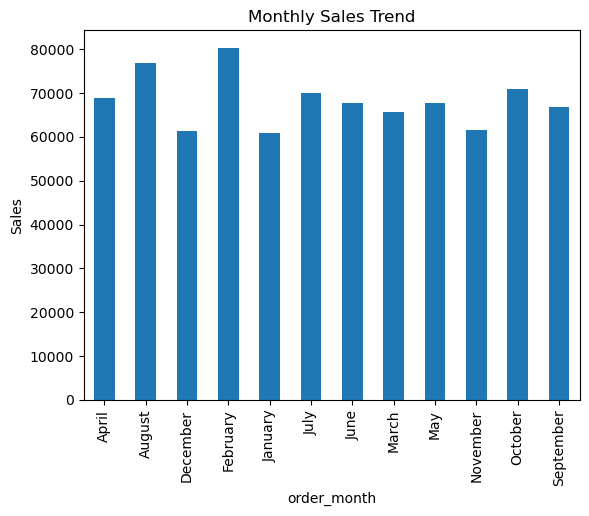

customer_id
C0399    9675.38
C0209    9546.48
C0386    8290.62
C0478    7786.44
C0203    7138.87
C0390    6549.75
C0630    6485.74
C0155    4679.56
C0633    4525.03
C0359    4434.69
Name: total_amount, dtype: float64


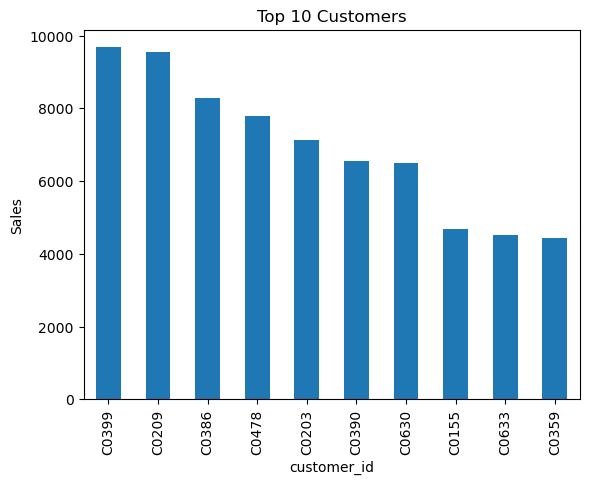

product_id
P0820    11698.98
P0336     9787.99
P0850     7834.59
P0053     7284.25
P0421     6973.23
P0181     6465.37
P0389     6321.11
P0564     5531.39
P0973     4475.98
P0267     4311.03
Name: total_amount, dtype: float64


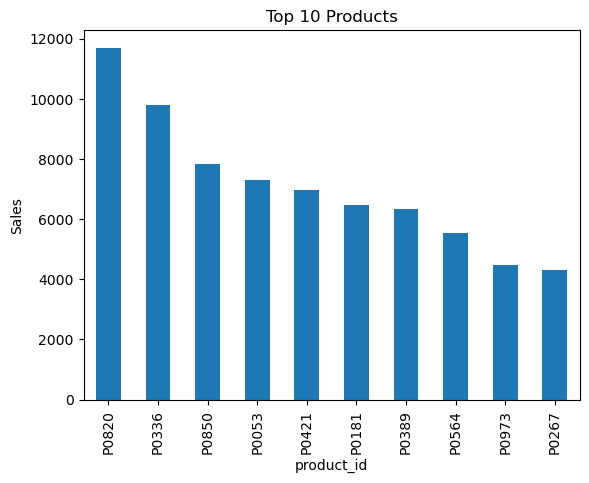

sales_channel
In-Store    578621.54
Online      239559.03
Name: total_amount, dtype: float64


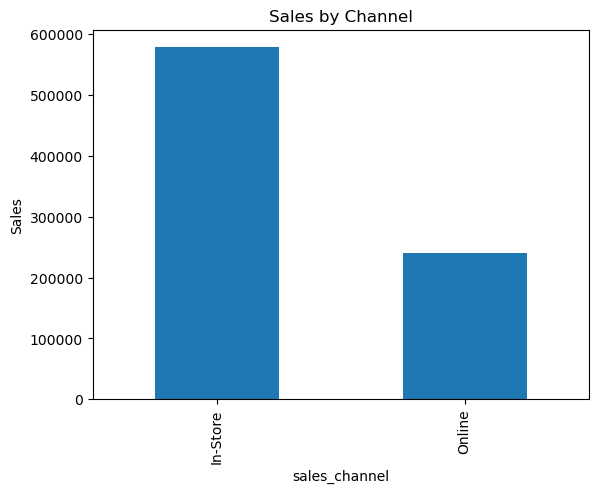

In [13]:
# ============================================================
# BASIC EDA
# ============================================================

import matplotlib.pyplot as plt

# 1. Sales Trend by Month
monthly_sales = sales.groupby('order_month')['total_amount'].sum()

print(monthly_sales)

monthly_sales.plot(kind='bar')
plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
plt.show()


# 2. Top 10 Customers by Sales
top_customers = sales.groupby('customer_id')['total_amount'].sum() \
                     .sort_values(ascending=False) \
                     .head(10)

print(top_customers)

top_customers.plot(kind='bar')
plt.title('Top 10 Customers')
plt.ylabel('Sales')
plt.show()


# 3. Top 10 Products by Sales
top_products = sales.groupby('product_id')['total_amount'].sum() \
                    .sort_values(ascending=False) \
                    .head(10)

print(top_products)

top_products.plot(kind='bar')
plt.title('Top 10 Products')
plt.ylabel('Sales')
plt.show()


# 4. Sales Channel Analysis
channel_sales = sales.groupby('sales_channel')['total_amount'].sum()

print(channel_sales)

channel_sales.plot(kind='bar')
plt.title('Sales by Channel')
plt.ylabel('Sales')
plt.show()

In [14]:
# ============================================================
# SAVE CLEANED DATA
# ============================================================

sales.to_csv("cleaned_sales.csv", index=False)
customers.to_csv("cleaned_customers.csv", index=False)
products.to_csv("cleaned_products.csv", index=False)
stores.to_csv("cleaned_stores.csv", index=False)
returns.to_csv("cleaned_returns.csv", index=False)

print("Cleaned files saved successfully!")

Cleaned files saved successfully!
